# Mangrove NDVI analysis: early warning signals + non-recovery detection

Two separate questions, both handled here:

1. **Early warning signals (prospective)** - Dakos et al. (2012) style. Looks at data *before* a decline for the statistical fingerprint of an approaching tipping point: rising autocorrelation (AR1), rising variance, changing skewness/kurtosis ("critical slowing down"). Tells you a shift may be **coming**.
2. **Non-recovery detection (retrospective)** - looks for a drop in NDVI that does not return to the prior healthy baseline. Tells you a shift **already happened** and, unlike a temporary dip, it stuck.

**Important:** when a shift is detected, the EWS indicators (part 1) are computed only on the segment *before* the shift onset, not the whole series. Fitting one smooth trend across an abrupt step blurs it into a gradual slope and produces a spurious spike in variance/autocorrelation right at the transition - a detrending artifact, not a real warning signal. Truncating to the pre-shift window avoids that.

Expects a CSV in the same long format the GEE export produces: columns `system:index` (point ID), `date`, `mean` (NDVI value).

Run the cells top to bottom. If `sisal.csv` isn't found, the last section auto-generates synthetic demo data so you can see the pipeline work regardless.

In [4]:
%matplotlib inline

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import os

## Config

Edit `input_csv` if your file has a different name or path.

In [6]:
CONFIG = {
    "input_csv": "code/Sisal_Landsat_NDVI_per_point_timeseries.csv",
    "output_dir": "ndvi_analysis_output",
    "min_months": 24,          # minimum length of a point's series to bother analyzing
    "max_gap_months": 2,       # interior gaps up to this long get linearly interpolated
    "min_completeness": 0.6,   # drop a point if less than this fraction of months are real/interpolated data
    "bandwidth_frac": 0.2,     # Gaussian detrending bandwidth, as a fraction of series length
    "window_frac": 0.5,        # rolling window for EWS indicators, as a fraction of series length (Dakos default)
    "n_surrogates": 200,       # surrogate resamples for significance testing (raise to ~1000 for final results)
    "baseline_frac": 0.25,     # fraction of the START of the series used as the "healthy" reference
    "tail_frac": 0.2,          # fraction of the END of the series checked for recovery
    "drop_k": 1.5,             # a point counts as "dropped" if smoothed NDVI falls this many baseline-SDs below baseline mean
    "recovery_k": 0.75,        # a point counts as "recovered" if the tail mean climbs back above baseline - this many SDs
    "min_duration_months": 6,  # how many consecutive months below the drop threshold before we call it a real onset (not noise)
    "random_seed": 0,
}

## 1. Loading and preprocessing

In [7]:
def load_long_csv(path):
    """Load the (point_id, date, ndvi) long-format CSV from a GEE export."""
    df = pd.read_csv(path)
    df = df.rename(columns={"system:index": "point_id", "mean": "ndvi"})
    df["date"] = pd.to_datetime(df["date"])
    return df[["point_id", "date", "ndvi"]]


def regularize_to_monthly(df, max_gap_months=2, min_completeness=0.6):
    """
    Turn irregular satellite-revisit data into an evenly-spaced monthly grid
    per point. Multiple observations in the same month are averaged; interior
    gaps up to `max_gap_months` are linearly interpolated; points with too
    much missing data even after that are dropped and reported.

    Regular spacing matters here because the rolling-window indicators below
    (AR1 in particular) assume roughly equal time steps between samples.
    """
    wide = df.pivot_table(index="date", columns="point_id", values="ndvi", aggfunc="mean")
    monthly = wide.resample("MS").mean()
    interpolated = monthly.interpolate(method="linear", limit=max_gap_months, limit_area="inside")

    completeness = interpolated.notna().mean()
    keep = completeness[completeness >= min_completeness].index
    dropped = completeness[completeness < min_completeness].index.tolist()

    cleaned = interpolated[keep]
    # Trim each column to its own valid range, then fill any remaining small
    # edge gaps. This is a simplification worth revisiting later (a proper
    # gap-aware estimator would be more rigorous), but is reasonable for a
    # first-pass analysis given min_completeness already filters out the
    # worst-affected points.
    cleaned = cleaned.apply(lambda s: s.loc[s.first_valid_index():s.last_valid_index()])
    cleaned = cleaned.ffill().bfill()

    return cleaned, dropped

## 2. Detrending

In [8]:
def detrend_gaussian(series, bandwidth_frac=0.2):
    """
    Gaussian-kernel smoothing to estimate the trend, then subtract it to get
    residuals - the same detrending approach used in the 'earlywarnings' R
    package (Dakos et al. 2012). EWS indicators are computed on the
    residuals, not the raw series, so a real long-term trend doesn't get
    mistaken for rising variance/autocorrelation.
    """
    n = len(series)
    sigma = max(1.0, bandwidth_frac * n)
    trend = gaussian_filter1d(series.values.astype(float), sigma=sigma, mode="nearest")
    residual = series.values - trend
    return (pd.Series(residual, index=series.index),
            pd.Series(trend, index=series.index))

## 3. Rolling EWS indicators (Tier 1: AR1, SD, skewness, kurtosis)

In [9]:
def rolling_ar1(x, window):
    """Rolling lag-1 autocorrelation. x is a numpy array."""
    n = len(x)
    out = np.full(n, np.nan)
    for i in range(window, n + 1):
        seg = x[i - window:i]
        a, b = seg[:-1], seg[1:]
        if np.std(a) == 0 or np.std(b) == 0:
            continue
        out[i - 1] = np.corrcoef(a, b)[0, 1]
    return out


def compute_indicators(residual_series, window):
    """Returns a DataFrame of rolling AR1, SD, skewness, kurtosis, indexed
    the same way as the input (so it lines up on a date axis when plotted)."""
    r = residual_series if isinstance(residual_series, pd.Series) else pd.Series(residual_series)
    return pd.DataFrame({
        "ar1": rolling_ar1(r.values, window),
        "sd": r.rolling(window).std().values,
        "skew": r.rolling(window).skew().values,
        "kurtosis": r.rolling(window).kurt().values,
    }, index=r.index)

## 4. Trend test + surrogate significance testing

In [10]:
def kendall_trend(values):
    """
    Kendall's tau between an indicator series and time. NOTE: we use tau
    itself but NOT scipy's built-in p-value - the rolling windows overlap,
    so successive indicator values aren't independent, and the standard
    p-value would be anti-conservative (falsely significant too often).
    Significance is assessed via surrogates instead (see below).
    """
    idx = np.arange(len(values))
    mask = ~np.isnan(values)
    if mask.sum() < 10:
        return np.nan
    tau, _ = kendalltau(idx[mask], np.asarray(values)[mask])
    return tau


def surrogate_pvalue(residual_values, window, indicator_key, observed_tau, n_surrogates, rng):
    """
    Null distribution for tau built by shuffling the residuals (destroying
    any real temporal structure) and recomputing the same indicator + trend
    test many times. p-value = fraction of surrogate taus >= the observed
    tau (one-sided: EWS theory predicts an INCREASE in AR1/SD/kurtosis
    approaching a tipping point, not a decrease).

    Caveat: shuffling destroys all autocorrelation, including any that's
    genuinely present but stable (not trending). A stricter test would use
    surrogates that preserve the fitted AR(1) structure while destroying
    only the trend (e.g. simulated AR(1) surrogates) - worth upgrading to
    if these results end up mattering a lot; flagged here as a Tier 2
    refinement rather than built in now.
    """
    surrogate_taus = np.empty(n_surrogates)
    rolling_method = {"sd": "std", "skew": "skew", "kurtosis": "kurt"}
    for i in range(n_surrogates):
        shuffled = rng.permutation(residual_values)
        if indicator_key == "ar1":
            ind = rolling_ar1(shuffled, window)
        else:
            s = pd.Series(shuffled)
            ind = getattr(s.rolling(window), rolling_method[indicator_key])().values
        surrogate_taus[i] = kendall_trend(ind)
    valid = surrogate_taus[~np.isnan(surrogate_taus)]
    if len(valid) == 0 or np.isnan(observed_tau):
        return np.nan
    return float(np.mean(valid >= observed_tau))

## 5. Non-recovery / regime-shift detection (retrospective)

**Important assumption:** this treats the *start* of each point's series as the healthy reference period. Reasonable if your record starts before any known disturbance, but worth checking `onset_date` against known events (hurricanes, HURDAT2 records) rather than trusting it blindly - especially for your purposively-selected disturbed sites.

In [11]:
def detect_non_recovery(series, baseline_frac=0.25, tail_frac=0.2,
                         drop_k=1.5, recovery_k=0.75, min_duration_months=6):
    """Did NDVI drop and fail to come back? Defines a healthy baseline from
    the start of the record, looks for a sustained drop below it, and
    checks whether the end of the record climbed back or stayed low."""
    n = len(series)
    baseline_n = max(3, int(n * baseline_frac))
    tail_n = max(3, int(n * tail_frac))

    baseline = series.iloc[:baseline_n]
    tail = series.iloc[-tail_n:]
    baseline_mean, baseline_std = baseline.mean(), baseline.std()

    drop_threshold = baseline_mean - drop_k * baseline_std
    recovery_threshold = baseline_mean - recovery_k * baseline_std

    smoothed = series.rolling(3, min_periods=1, center=True).mean()
    below = smoothed < drop_threshold

    onset_date = None
    run_length = 0
    for date, flag in below.items():
        if flag:
            run_length += 1
            if run_length == min_duration_months:
                onset_date = date - pd.DateOffset(months=min_duration_months - 1)
                break
        else:
            run_length = 0

    tail_mean = tail.mean()
    shift_detected = onset_date is not None
    recovered = bool(tail_mean >= recovery_threshold) if shift_detected else None

    return {
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
        "drop_threshold": drop_threshold,
        "shift_detected": shift_detected,
        "onset_date": onset_date,
        "tail_mean": tail_mean,
        "recovered": recovered,
    }

## 6. Per-point pipeline

In [12]:
def analyze_point(point_id, raw_series, config, rng):
    n_total = len(raw_series)
    if n_total < config["min_months"]:
        return None

    # Non-recovery / shift detection runs FIRST, on the full series - we need
    # to know if/where a transition happened before we can detrend correctly.
    shift_info = detect_non_recovery(
        raw_series,
        baseline_frac=config["baseline_frac"],
        tail_frac=config["tail_frac"],
        drop_k=config["drop_k"],
        recovery_k=config["recovery_k"],
        min_duration_months=config["min_duration_months"],
    )

    # IMPORTANT: if a shift was detected, restrict the prospective EWS
    # analysis (detrending + rolling indicators) to the segment BEFORE the
    # shift. Fitting one smooth trend across an abrupt step blurs the step
    # into a gradual slope, which then produces a large but SPURIOUS spike
    # in variance/autocorrelation right at the transition - a detrending
    # artifact, not a real early-warning signal. EWS indicators are only
    # meaningful for data leading up to a transition, never data that
    # straddles one.
    if shift_info["shift_detected"] and shift_info["onset_date"] is not None:
        analysis_series = raw_series.loc[:shift_info["onset_date"]].iloc[:-1]
    else:
        analysis_series = raw_series

    result = {"point_id": point_id, "n_months": n_total, "n_preshift_months": len(analysis_series)}
    result.update({f"shift_{k}": v for k, v in shift_info.items()})

    n_analysis = len(analysis_series)
    window = max(12, int(n_analysis * config["window_frac"])) if n_analysis > 0 else None

    if n_analysis < config["min_months"] or window >= n_analysis:
        # Not enough pre-shift data to say anything about early warning
        # signals - still report the shift/non-recovery result above.
        for key in ["ar1", "sd", "skew", "kurtosis"]:
            result[f"tau_{key}"] = np.nan
            result[f"p_{key}"] = np.nan
        return result, None, None, None

    residual, trend = detrend_gaussian(analysis_series, config["bandwidth_frac"])
    indicators = compute_indicators(residual, window)

    for key in ["ar1", "sd", "skew", "kurtosis"]:
        tau = kendall_trend(indicators[key].values)
        pval = surrogate_pvalue(residual.values, window, key,
                                 tau, config["n_surrogates"], rng)
        result[f"tau_{key}"] = tau
        result[f"p_{key}"] = pval

    return result, residual, trend, indicators


def run_analysis(config):
    os.makedirs(config["output_dir"], exist_ok=True)
    df = load_long_csv(config["input_csv"])
    monthly, dropped = regularize_to_monthly(
        df, config["max_gap_months"], config["min_completeness"]
    )
    if dropped:
        print(f"Dropped {len(dropped)} point(s) for insufficient data coverage: {dropped}")

    rng = np.random.default_rng(config["random_seed"])
    rows = []
    detail = {}  # point_id -> residual/trend/indicators, kept for plotting

    for point_id in monthly.columns:
        series = monthly[point_id].dropna()
        out = analyze_point(point_id, series, config, rng)
        if out is None:
            continue
        row, residual, trend, indicators = out
        rows.append(row)
        detail[point_id] = {"raw": series, "residual": residual, "trend": trend, "indicators": indicators}

    results_df = pd.DataFrame(rows)
    out_path = os.path.join(config["output_dir"], "ews_summary.csv")
    results_df.to_csv(out_path, index=False)
    print(f"Analyzed {len(results_df)} points. Summary written to {out_path}")

    return results_df, detail, monthly

## 7. Plotting

In [13]:
def plot_point(point_id, detail, results_row, output_dir, save=True):
    raw = detail["raw"]
    residual = detail["residual"]
    trend = detail["trend"]
    indicators = detail["indicators"]

    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)

    axes[0].plot(raw.index, raw.values, color="tab:green", label="NDVI")
    if trend is not None:
        axes[0].plot(trend.index, trend.values, color="black", linestyle="--",
                     label="trend (Gaussian, pre-shift only)" if results_row.get("shift_shift_detected") else "trend (Gaussian)")
    if results_row is not None and results_row.get("shift_shift_detected"):
        axes[0].axhline(results_row["shift_drop_threshold"], color="red", linestyle=":", label="drop threshold")
        if results_row.get("shift_onset_date") is not None:
            axes[0].axvline(results_row["shift_onset_date"], color="red", alpha=0.6, label="shift onset")
    axes[0].set_ylabel("NDVI")
    axes[0].legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"Point {point_id}")

    if residual is not None:
        axes[1].plot(residual.index, residual.values, color="tab:blue")
        axes[1].axhline(0, color="gray", linewidth=0.8)
        axes[1].set_ylabel("Detrended\nresidual\n(pre-shift)")
    else:
        axes[1].text(0.5, 0.5, "Not enough pre-shift data for EWS analysis",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=9, color="gray")

    if indicators is not None:
        axes[2].plot(indicators.index, indicators["ar1"], color="tab:orange", label="AR1")
        ax2b = axes[2].twinx()
        ax2b.plot(indicators.index, indicators["sd"], color="tab:purple", alpha=0.6, label="SD")
        axes[2].set_ylabel("Rolling AR1", color="tab:orange")
        ax2b.set_ylabel("Rolling SD", color="tab:purple")

        axes[3].plot(indicators.index, indicators["skew"], color="tab:red", label="skewness")
        ax3b = axes[3].twinx()
        ax3b.plot(indicators.index, indicators["kurtosis"], color="tab:brown", alpha=0.6, label="kurtosis")
        axes[3].set_ylabel("Skewness", color="tab:red")
        ax3b.set_ylabel("Kurtosis", color="tab:brown")
    axes[3].set_xlabel("Date")

    fig.tight_layout()
    plt.show()
    if save:
        path = os.path.join(output_dir, f"point_{point_id}.png")
        fig.savefig(path, dpi=120)
        plt.close(fig)
        return path
    plt.close(fig)
    return None

## 8. Synthetic demo data

Only used if `sisal.csv` isn't found - lets you see the pipeline work before your real file is ready.

In [14]:
def make_synthetic_demo(n_points=8, n_months=120, seed=1):
    """
    Builds a fake long-format CSV resembling your GEE export, with a mix of:
      - stable healthy points (noisy, no trend)
      - a point with a temporary dip that recovers
      - a point with an abrupt drop that does NOT recover
      - a point with a gradual decline + rising variance before a shift
        (a textbook critical-slowing-down example)
    """
    rng = np.random.default_rng(seed)
    dates = pd.date_range("2015-01-01", periods=n_months, freq="MS")
    rows = []

    for p in range(n_points):
        base = 0.7 + rng.normal(0, 0.02)
        noise_sd = 0.03
        series = base + rng.normal(0, noise_sd, n_months)

        if p == 2:  # temporary dip, recovers
            dip_start, dip_len = 40, 8
            series[dip_start:dip_start + dip_len] -= 0.25
        elif p == 3:  # abrupt drop, no recovery
            shift_at = 60
            series[shift_at:] -= 0.3
        elif p == 4:  # gradual decline + rising variance before a shift
            shift_at = 80
            ramp = np.linspace(0, 1, shift_at)
            series[:shift_at] += -0.15 * ramp + rng.normal(0, noise_sd * (1 + 2 * ramp), shift_at) - rng.normal(0, noise_sd, shift_at)
            series[shift_at:] -= 0.25

        series = np.clip(series, 0.05, 0.95)
        keep_mask = rng.random(n_months) > 0.15  # simulate irregular satellite sampling
        for d, v, keep in zip(dates, series, keep_mask):
            if keep:
                rows.append({"system:index": f"pt_{p:03d}", "date": d.strftime("%Y-%m-%d"), "mean": v})

    return pd.DataFrame(rows)

## Run the analysis

In [15]:
if not os.path.exists(CONFIG["input_csv"]):
    print(f"'{CONFIG['input_csv']}' not found - running on synthetic demo data instead.")
    print("Once sisal.csv is in this folder, just re-run the notebook from the top.\n")
    demo_df = make_synthetic_demo()
    demo_path = "demo_ndvi_timeseries.csv"
    demo_df.to_csv(demo_path, index=False)
    CONFIG["input_csv"] = demo_path

results_df, detail, monthly = run_analysis(CONFIG)
results_df

'code/Sisal_Landsat_NDVI_per_point_timeseries.csv' not found - running on synthetic demo data instead.
Once sisal.csv is in this folder, just re-run the notebook from the top.

Analyzed 8 points. Summary written to ndvi_analysis_output/ews_summary.csv


,point_id,n_months,n_preshift_months,shift_baseline_mean,shift_baseline_std,shift_drop_threshold,shift_shift_detected,shift_onset_date,shift_tail_mean,shift_recovered,tau_ar1,p_ar1,tau_sd,p_sd,tau_skew,p_skew,tau_kurtosis,p_kurtosis
0,pt_000,120,120,0.705064,0.026873,0.664755,False,NaT,0.717398,None,-0.071038,0.570,-0.396721,0.740,0.107104,0.410,-0.691803,0.970
1,pt_001,120,120,0.679516,0.024369,0.642962,False,NaT,0.689047,None,0.723497,0.060,-0.251366,0.665,-0.322404,0.710,-0.597814,0.865
2,pt_002,120,39,0.687888,0.030701,0.641837,True,2018-04-01,0.672480,True,-0.333333,0.660,0.580952,0.135,0.485714,0.195,-0.752381,0.985
3,pt_003,120,59,0.717263,0.027228,0.676421,True,2019-12-01,0.415766,False,-0.513978,0.785,0.023656,0.565,0.221505,0.360,0.690323,0.055
4,pt_004,120,78,0.696948,0.060268,0.606546,True,2021-07-01,0.493993,False,-0.882051,0.990,0.415385,0.210,-0.012821,0.435,-0.176923,0.600
5,pt_005,120,120,0.671079,0.030044,0.626014,False,NaT,0.672076,None,0.380328,0.370,-0.489617,0.745,-0.408743,0.765,0.284153,0.375
6,pt_006,120,120,0.675433,0.030688,0.629401,False,NaT,0.673117,None,0.740984,0.070,0.158470,0.430,-0.511475,0.795,-0.003279,0.505
7,pt_007,120,120,0.723146,0.025844,0.684381,False,NaT,0.731794,None,-0.884153,1.000,0.323497,0.340,-0.624044,0.910,0.217486,0.385


## Plot results

Shows the first 5 analyzed points by default - change the slice (or filter `results_df` first, e.g. to only rows where `shift_shift_detected` is True) to look at specific points.

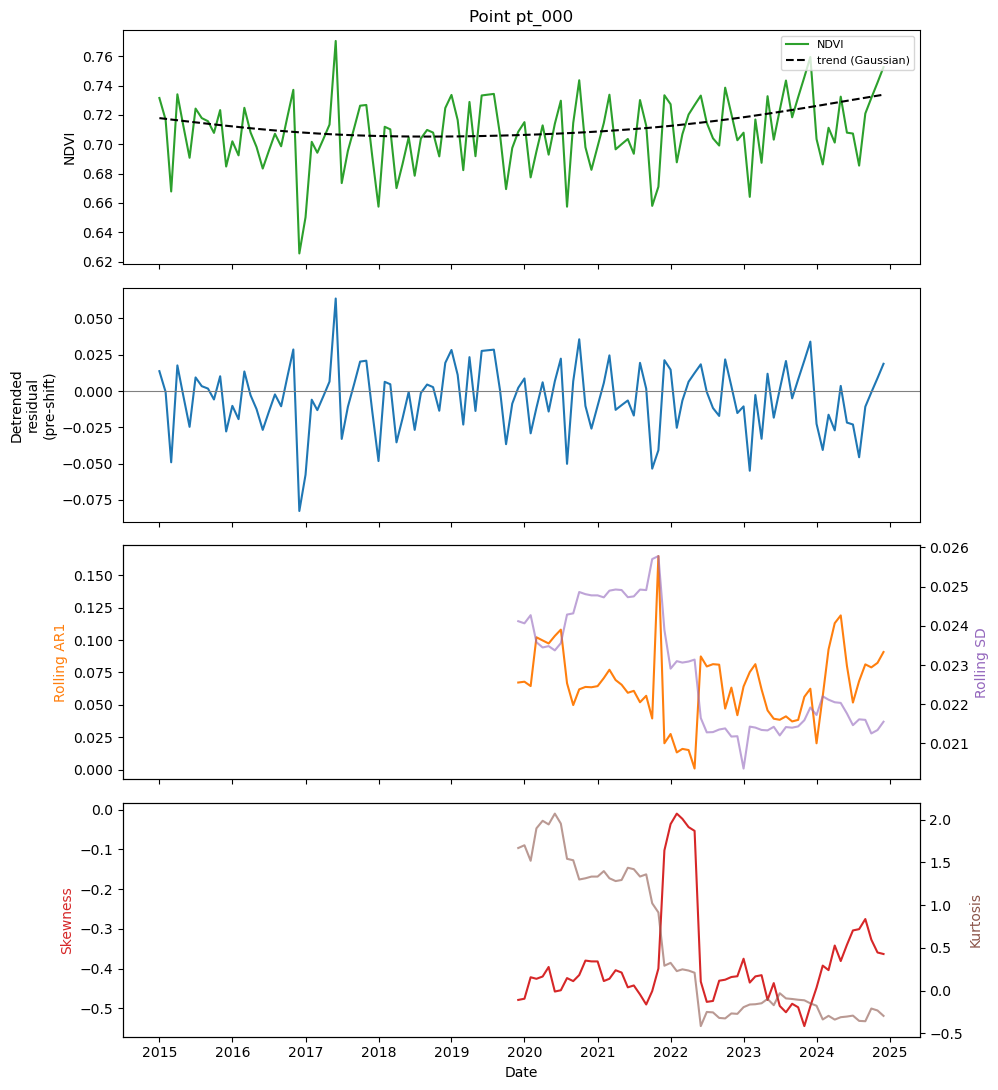

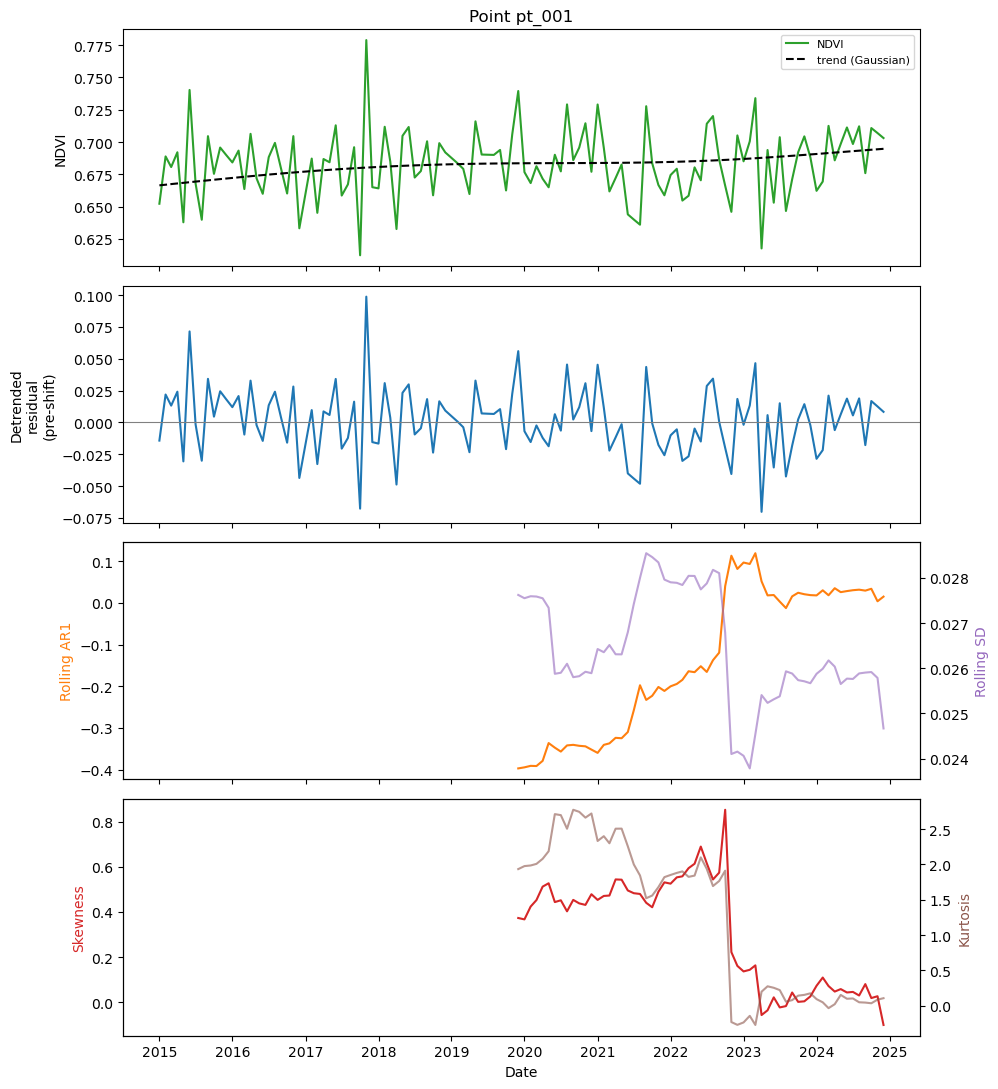

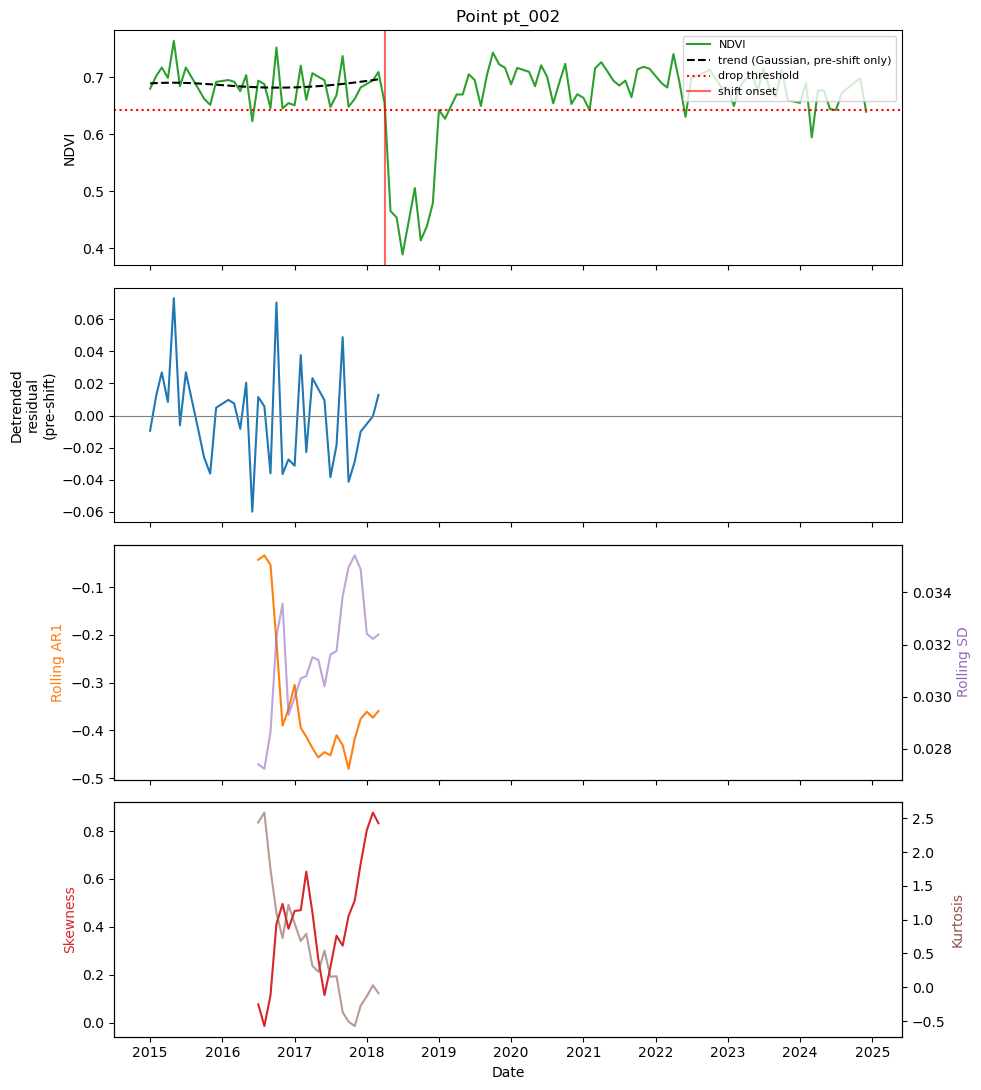

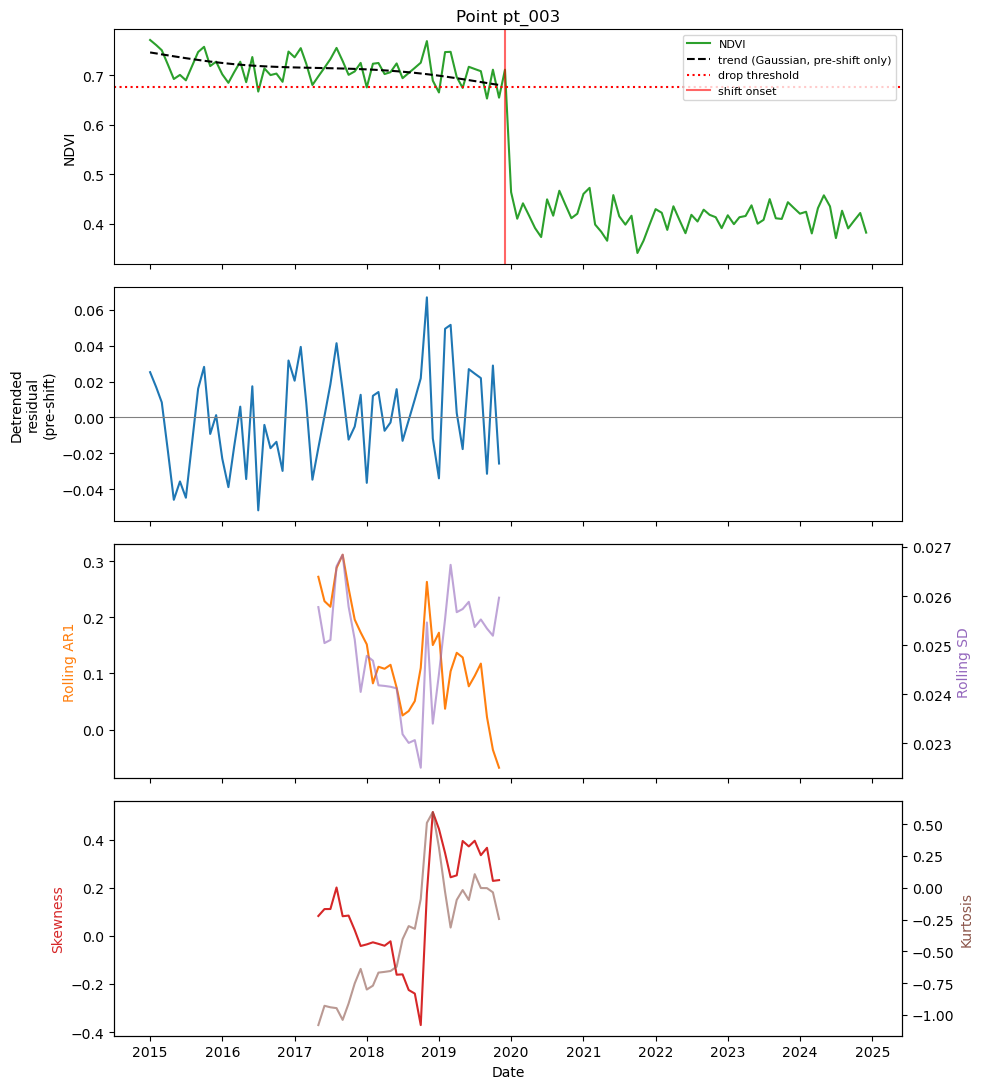

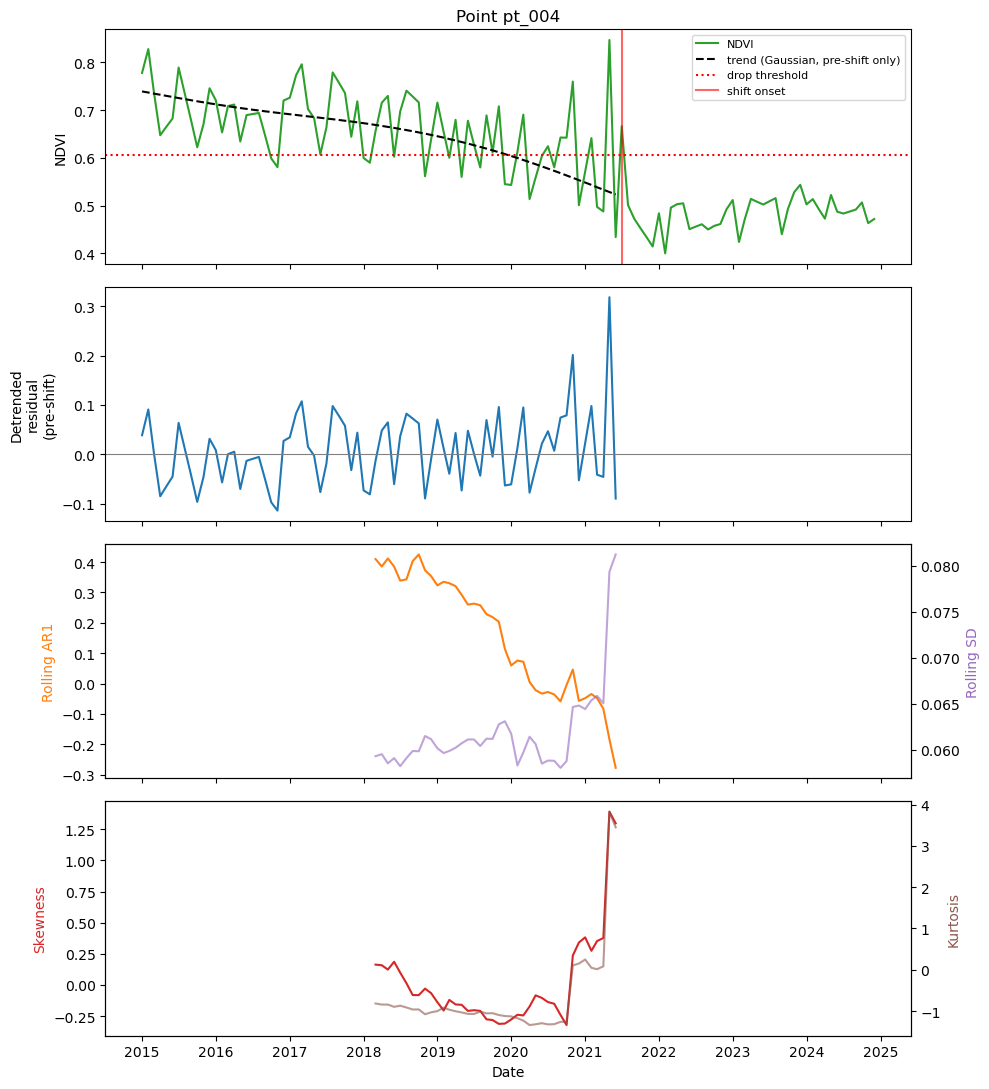

In [16]:
for _, row in results_df.head(5).iterrows():
    pid = row["point_id"]
    plot_point(pid, detail[pid], row, CONFIG["output_dir"])